# YouDo 2 — Sparse Movie Rating Tahmini

Bu notebook'ta amaç: `userId`, `movieId`, `rating` datasından eksik ratingleri tahmin etmek.

Ana karar şu: Data sparse olduğu için eksik ratingleri **0 gibi davranmıyoruz**. Sadece gerçekten verilmiş rating satırlarıyla çalışıyoruz.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from io import StringIO
from pathlib import Path
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 120

## 1. Datayı yükle

Önce `ratings_long.csv` varsa onu okuyoruz. Yoksa notebook içindeki örnek data ile çalışıyor.

Ek kontrol: Aynı kullanıcı aynı filme birden fazla rating verdiyse, tek satıra indirip ortalamasını alıyoruz.

In [2]:
DATA_PATH = Path("ratings_long.csv")

SAMPLE_DATA = """
1 0 16 5
2 0 72 5
3 0 86 5
4 0 259 1
5 0 319 4
6 0 521 4
7 0 534 2
8 0 671 1
9 0 673 2
10 0 739 3
11 0 764 2
12 0 798 3
13 0 917 4
14 1 87 1
15 1 125 5
16 1 129 1
17 1 148 1
18 1 248 2
19 1 261 2
20 1 286 5
21 1 323 1
22 1 336 5
23 1 393 2
24 1 397 5
25 1 411 1
26 1 497 4
27 1 522 1
28 1 542 2
29 1 603 3
30 1 708 2
31 1 875 5
32 1 902 1
33 1 910 5
34 1 998 4
35 2 184 3
36 2 242 3
37 2 391 3
38 2 455 4
39 2 543 4
40 2 638 2
41 2 777 4
42 2 831 3
43 2 853 3
44 2 871 3
45 2 907 3
46 2 923 3
47 2 933 3
48 3 75 4
49 3 275 4
50 3 360 1
51 3 428 5
52 3 457 2
53 3 458 3
54 3 476 3
55 3 644 3
56 3 693 2
57 3 746 3
58 3 758 5
59 3 883 4
60 3 894 2
61 4 219 2
62 4 307 3
63 4 602 3
64 4 657 3
65 4 758 4
66 4 881 3
67 5 71 2
68 5 116 5
69 5 119 1
70 5 376 1
71 5 428 4
72 5 477 4
73 5 603 4
74 5 740 2
75 5 767 5
76 5 791 3
77 5 872 4
78 5 901 3
79 5 908 3
80 5 966 5
81 6 10 4
82 6 173 4
83 6 195 3
84 6 583 4
85 6 602 3
86 6 677 3
87 6 782 4
88 6 918 3
89 7 17 2
90 7 19 5
91 7 83 3
92 7 252 5
93 7 328 2
94 7 459 4
95 7 731 5
96 7 854 2
97 8 44 1
98 8 310 3
99 8 784 5
100 9 236 4
101 9 246 3
102 9 311 4
103 9 503 2
104 9 581 2
105 9 666 2
106 9 691 3
107 9 780 3
108 10 20 1
109 10 89 4
110 10 365 1
111 10 469 1
112 10 705 3
113 10 744 5
114 10 770 1
115 11 23 2
116 11 59 1
117 11 116 3
118 11 142 2
119 11 262 1
120 11 312 3
121 11 337 2
122 11 459 5
123 11 534 5
124 11 780 4
125 11 792 5
126 11 872 1
127 11 933 3
128 12 5 3
129 12 101 2
130 12 197 2
131 12 432 4
132 12 508 5
133 12 677 2
134 12 907 1
135 12 948 2
136 12 955 2
137 13 88 4
138 13 356 1
139 13 445 4
140 13 480 2
141 13 534 5
142 13 719 2
143 13 879 3
144 13 897 1
145 13 942 3
146 13 994 2
147 14 111 3
148 14 128 4
149 14 198 3
150 14 284 3
151 14 471 5
152 14 573 1
153 14 679 4
154 14 786 2
155 14 931 3
156 15 71 5
157 15 113 4
158 15 140 5
159 15 179 3
160 15 181 3
161 15 390 1
162 15 412 2
163 15 536 2
164 15 752 4
165 15 779 2
166 15 941 3
167 16 14 2
168 16 143 3
169 16 203 1
170 16 217 3
171 16 218 3
172 16 332 4
173 16 392 3
174 16 437 3
175 16 692 3
176 16 697 3
177 16 915 2
178 16 916 2
179 17 16 5
180 17 22 5
181 17 201 4
182 17 241 4
183 18 183 3
184 18 276 5
185 18 395 4
186 18 510 5
187 18 572 5
188 18 640 2
189 18 697 4
190 18 739 3
191 19 148 1
192 19 369 5
193 19 464 5
194 19 501 2
195 19 572 1
196 19 573 5
197 19 607 5
198 19 611 1
199 19 721 3
200 19 739 5"""

if DATA_PATH.exists():
    df_raw = pd.read_csv(DATA_PATH)
else:
    df_raw = pd.read_csv(
        StringIO(SAMPLE_DATA),
        sep=r"\s+",
        header=None,
        names=["row_id", "userId", "movieId", "rating"]
    ).drop(columns="row_id")

df = df_raw[["userId", "movieId", "rating"]].copy()
df["userId"] = df["userId"].astype(int)
df["movieId"] = df["movieId"].astype(int)
df["rating"] = df["rating"].astype(float)

# Aynı user-film çifti tekrar ederse veri kaçağı/çakışma olmasın.
duplicate_count = df.duplicated(["userId", "movieId"]).sum()
df = (
    df.groupby(["userId", "movieId"], as_index=False)["rating"]
    .mean()
)

print("Tekrar eden user-movie satırı:", duplicate_count)
df.head()

Tekrar eden user-movie satırı: 0


,userId,movieId,rating
0,0,16,5.0
1,0,72,5.0
2,0,86,5.0
3,0,259,1.0
4,0,319,4.0


## 2. ID'leri iç indekslere çevir

`movieId` ve `userId` sadece kimliktir. Özellikle `movieId=998` demek 999 tane film var demek değildir.

Bu yüzden model içinde küçük ve düzgün indeksler kullanıyoruz:

- `user_idx`: modelin kullanıcı indeksi
- `movie_idx`: modelin film indeksi

Çıktıda yine gerçek `movieId` gösteriyoruz.

In [3]:
user_values = np.sort(df["userId"].unique())
movie_values = np.sort(df["movieId"].unique())

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_values)}
idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}

movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_values)}
idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}

df["user_idx"] = df["userId"].map(user_to_idx).astype(int)
df["movie_idx"] = df["movieId"].map(movie_to_idx).astype(int)

df.head()

,userId,movieId,rating,user_idx,movie_idx
0,0,16,5.0,0,3
1,0,72,5.0,0,12
2,0,86,5.0,0,15
3,0,259,1.0,0,50
4,0,319,4.0,0,61


## 3. Hızlı data kontrolü

Burada data ne kadar sparse onu netleştiriyoruz. Bu karar bütün model seçimini etkiliyor.

Not: Sparsity hesabında `max(movieId)` değil, **benzersiz film sayısı** kullanıldı.

In [4]:
n_users = df["user_idx"].nunique()
n_movies = df["movie_idx"].nunique()
n_observed = len(df)
n_possible = n_users * n_movies
sparsity = 1 - (n_observed / n_possible)

summary = pd.DataFrame({
    "metrik": ["kullanıcı sayısı", "benzersiz film sayısı", "observed rating", "olası user-film çifti", "sparsity"],
    "değer": [n_users, n_movies, n_observed, n_possible, f"{sparsity:.2%}"]
})
summary

,metrik,değer
0,kullanıcı sayısı,20
1,benzersiz film sayısı,179
2,observed rating,200
3,olası user-film çifti,3580
4,sparsity,94.41%


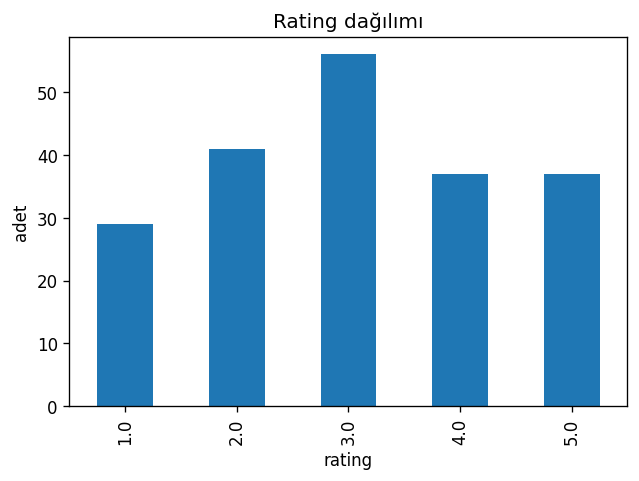

,adet
rating,
1.0,29
2.0,41
3.0,56
4.0,37
5.0,37


In [5]:
rating_dist = df["rating"].value_counts().sort_index()

ax = rating_dist.plot(kind="bar", figsize=(6, 4))
ax.set_title("Rating dağılımı")
ax.set_xlabel("rating")
ax.set_ylabel("adet")
plt.show()

rating_dist.to_frame("adet")

## 3.1. Kullanıcı ve film yoğunluğu

Sparse datada sadece ortalama ratinge bakmak yetmez. Kim kaç film puanlamış ve filmler kaç kez görülmüş, bunu da kontrol ediyoruz.

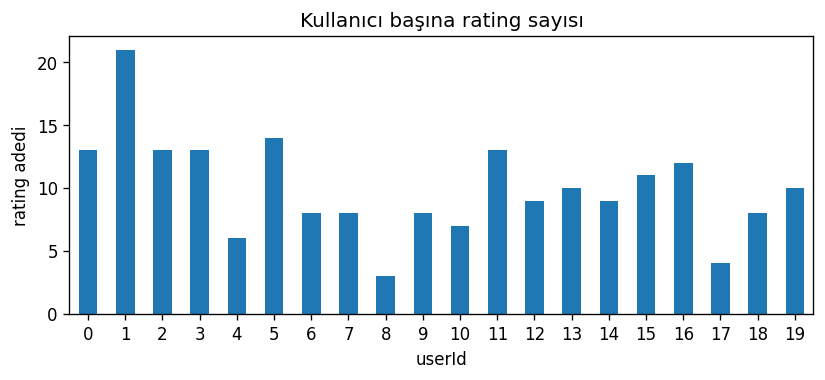

,kullanıcı rating sayısı
count,20.000000
mean,10.000000
std,4.013136
min,3.000000
25%,8.000000
50%,9.500000
75%,13.000000
max,21.000000


In [6]:
user_counts = df.groupby("userId").size()

ax = user_counts.plot(kind="bar", figsize=(8, 3))
ax.set_title("Kullanıcı başına rating sayısı")
ax.set_xlabel("userId")
ax.set_ylabel("rating adedi")
plt.xticks(rotation=0)
plt.show()

user_counts.describe().to_frame("kullanıcı rating sayısı")

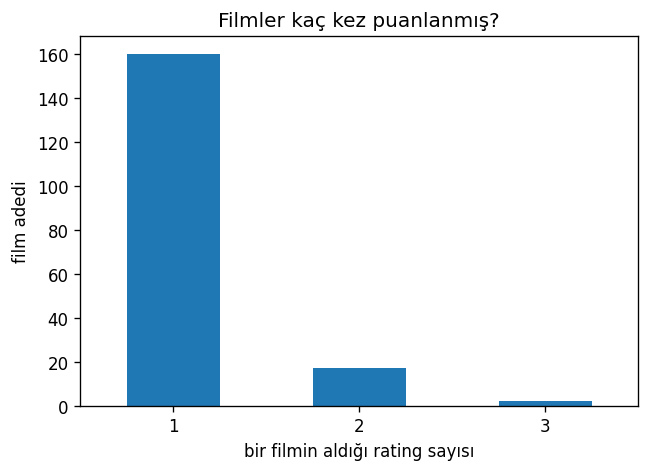

,film adedi
1,160
2,17
3,2


In [7]:
movie_counts = df.groupby("movieId").size()
movie_count_dist = movie_counts.value_counts().sort_index()

ax = movie_count_dist.plot(kind="bar", figsize=(6, 4))
ax.set_title("Filmler kaç kez puanlanmış?")
ax.set_xlabel("bir filmin aldığı rating sayısı")
ax.set_ylabel("film adedi")
plt.xticks(rotation=0)
plt.show()

movie_count_dist.to_frame("film adedi")

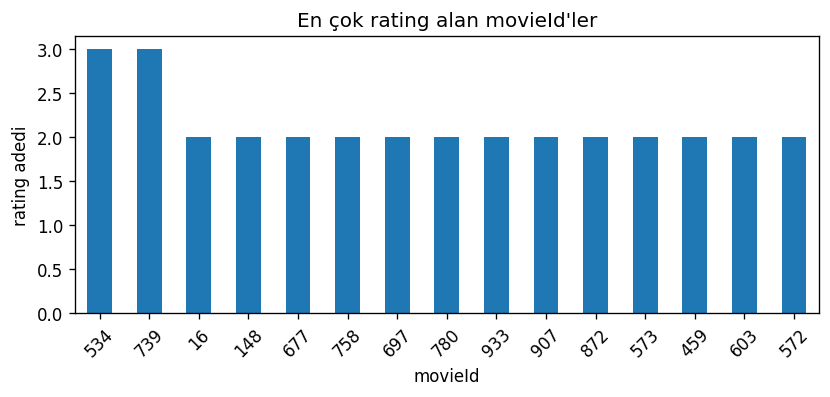

,rating adedi
movieId,
534,3
739,3
16,2
148,2
677,2
758,2
697,2
780,2
933,2


In [8]:
top_movies = movie_counts.sort_values(ascending=False).head(15)

ax = top_movies.plot(kind="bar", figsize=(8, 3))
ax.set_title("En çok rating alan movieId'ler")
ax.set_xlabel("movieId")
ax.set_ylabel("rating adedi")
plt.xticks(rotation=45)
plt.show()

top_movies.to_frame("rating adedi")

## 4. Sparse matrix görünümü

Bu matrisi modele direkt doldurmuyoruz. Sadece sparse yapıyı görmek için kuruyoruz.

Eksik yerler `NaN`, çünkü kullanıcı o filme rating vermemiş.

In [9]:
R = np.full((n_users, n_movies), np.nan)

for row in df.itertuples(index=False):
    R[row.user_idx, row.movie_idx] = row.rating

pd.DataFrame(R).iloc[:5, :20]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


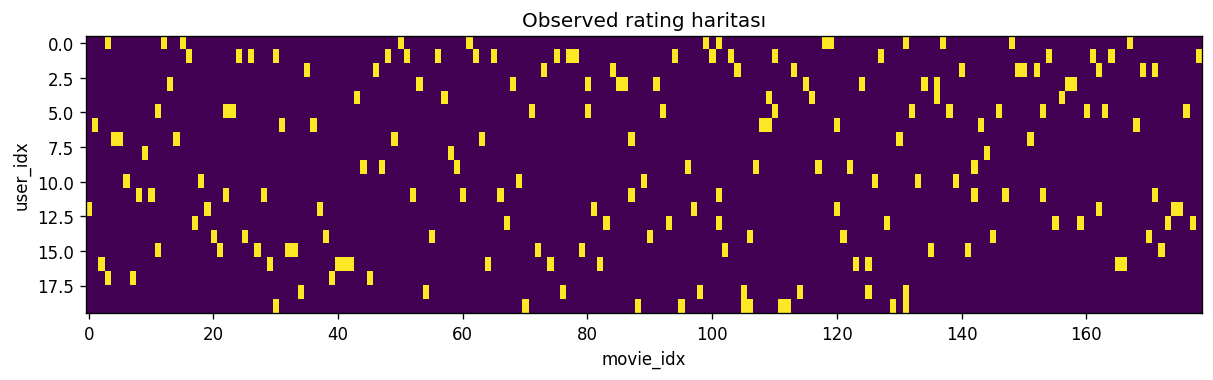

In [10]:
observed_mask = ~np.isnan(R)

plt.figure(figsize=(12, 3))
plt.imshow(observed_mask, aspect="auto", interpolation="nearest")
plt.title("Observed rating haritası")
plt.xlabel("movie_idx")
plt.ylabel("user_idx")
plt.show()

## 4.1. Akıllı ama doğru fikir

MovieId için sin/cos dönüşümü yapmadık. Çünkü movieId sıralı veya dairesel bir değer değil.

Bu probleme daha uygun fikir: **user-centered rating**.

Yani ratingi kullanıcının kendi ortalamasına göre düşünmek:

\[
centered\ rating = rating - user\ mean
\]

Çünkü bazı kullanıcılar genel olarak yüksek puan verir, bazıları daha sert puanlar. Model bunu hesaba katmalı.

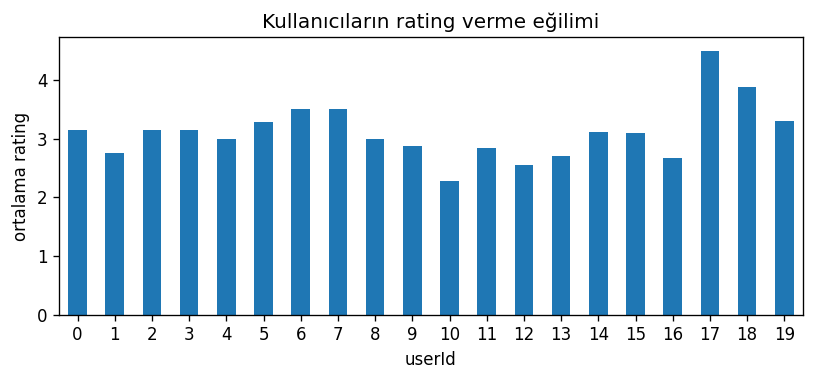

,rating_sayısı,ortalama_rating,rating_std
userId,,,
0,13,3.154,1.463
1,21,2.762,1.700
2,13,3.154,0.555
3,13,3.154,1.214
4,6,3.000,0.632
5,14,3.286,1.383
6,8,3.500,0.535
7,8,3.500,1.414
8,3,3.000,2.000


In [11]:
user_profile = (
    df.groupby("userId")["rating"]
    .agg(["count", "mean", "std"])
    .rename(columns={"count": "rating_sayısı", "mean": "ortalama_rating", "std": "rating_std"})
    .fillna(0)
    .round(3)
)

ax = user_profile["ortalama_rating"].plot(kind="bar", figsize=(8, 3))
ax.set_title("Kullanıcıların rating verme eğilimi")
ax.set_xlabel("userId")
ax.set_ylabel("ortalama rating")
plt.xticks(rotation=0)
plt.show()

user_profile

## 5. Split stratejisi

Bu problemde normal classification accuracy mantıklı değil. Çünkü hedef 1-5 arası rating tahmini.

Bu yüzden:

- Split sadece **observed rating satırları** üzerinden yapıldı.
- Rating dağılımı bozulmasın diye mümkünse **Stratified K-Fold** kullanıldı.
- Metrik olarak **RMSE** ve **MAE** kullanıldı.
- Missing ratingler asla 0 yapılmadı.

In [12]:
def make_cv_splits(data, n_splits=5, random_state=42):
    # Rating dağılımı uygunsa stratified K-Fold döndürür.
    y = data["rating"].astype(int)
    min_class_count = y.value_counts().min()

    if min_class_count >= n_splits:
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )
        split_name = "StratifiedKFold"
        splits = splitter.split(data, y)
    else:
        splitter = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )
        split_name = "KFold"
        splits = splitter.split(data)

    return split_name, list(splits)

split_name, cv_splits = make_cv_splits(df, n_splits=5, random_state=RANDOM_STATE)
print("Kullanılan split:", split_name)
print("Fold sayısı:", len(cv_splits))

Kullanılan split: StratifiedKFold
Fold sayısı: 5


## 5.1. Split teşhisi

Data sadece sparse değil, film tarafında da çok dağınık. Testteki bazı filmler train içinde hiç görülmemiş olabilir.

Bu durumda model o film için item bilgisi öğrenemez. O yüzden fallback kullanmak doğru hamle.

In [13]:
fold_checks = []

for fold, (train_idx, test_idx) in enumerate(cv_splits, start=1):
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    train_users = set(train_df["userId"])
    train_items = set(train_df["movieId"])

    fold_checks.append({
        "fold": fold,
        "test kullanıcı train'de var oranı": test_df["userId"].isin(train_users).mean(),
        "test film train'de var oranı": test_df["movieId"].isin(train_items).mean(),
        "train rating": len(train_df),
        "test rating": len(test_df)
    })

fold_checks = pd.DataFrame(fold_checks)
fold_checks

,fold,test kullanıcı train'de var oranı,test film train'de var oranı,train rating,test rating
0,1,1.0,0.150,160,40
1,2,1.0,0.175,160,40
2,3,1.0,0.175,160,40
3,4,1.0,0.125,160,40
4,5,1.0,0.125,160,40


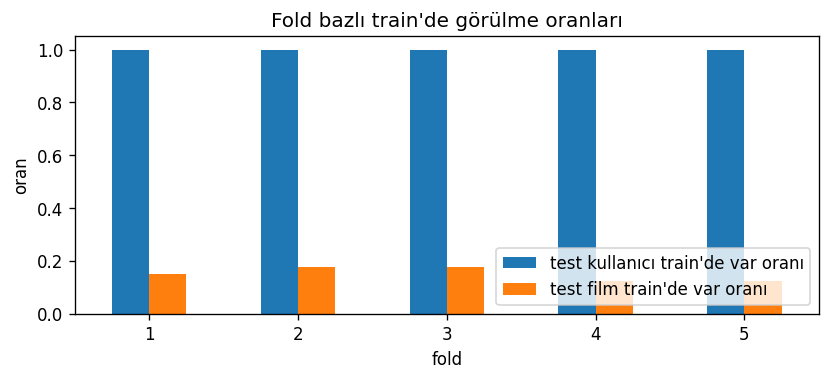

In [14]:
ax = fold_checks.plot(
    x="fold",
    y=["test kullanıcı train'de var oranı", "test film train'de var oranı"],
    kind="bar",
    figsize=(8, 3)
)
ax.set_title("Fold bazlı train'de görülme oranları")
ax.set_xlabel("fold")
ax.set_ylabel("oran")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## 5.2. Loss notu

Matrix factorization loss'u pratikte şu şekilde kuruyoruz:

\[
\sum_{(u,i) \in observed} (r_{ui} - \hat r_{ui})^2 + \lambda(||U||^2 + ||V||^2)
\]

Burada önemli detay: Bu loss **U ve V için beraber bakınca joint convex değildir**. Bu yüzden sonucu baseline ile dürüstçe kıyaslıyoruz.

## 6. Baseline model

Önce basit ama güçlü bir baseline kuruyoruz.

Tahmin mantığı:

`global_mean + user_bias + item_bias`

Sparse datada bu baseline önemli. Bundan iyi olmayan model ekstra değer katmamış demektir.

In [15]:
class BiasBaseline:
    def __init__(self, shrinkage=5.0, min_rating=1.0, max_rating=5.0):
        self.shrinkage = shrinkage
        self.min_rating = min_rating
        self.max_rating = max_rating

    def fit(self, train_df):
        self.global_mean_ = train_df["rating"].mean()

        user_stats = train_df.groupby("userId")["rating"].agg(["mean", "count"])
        item_stats = train_df.groupby("movieId")["rating"].agg(["mean", "count"])

        # Az ratingli kullanıcı/film bias'larını küçültüyoruz.
        self.user_bias_ = (
            (user_stats["mean"] - self.global_mean_) *
            user_stats["count"] / (user_stats["count"] + self.shrinkage)
        ).to_dict()

        self.item_bias_ = (
            (item_stats["mean"] - self.global_mean_) *
            item_stats["count"] / (item_stats["count"] + self.shrinkage)
        ).to_dict()
        return self

    def predict(self, data):
        preds = []
        for row in data.itertuples(index=False):
            pred = self.global_mean_
            pred += self.user_bias_.get(row.userId, 0.0)
            pred += self.item_bias_.get(row.movieId, 0.0)
            preds.append(np.clip(pred, self.min_rating, self.max_rating))
        return np.array(preds)

## 7. Ek strateji: User-centered Item KNN

Bu notebook'taki ekstra fikir bu.

Mantık şu:

- Her kullanıcının ortalamasını bul.
- Ratingi `rating - kullanıcı ortalaması` şeklinde merkeze çek.
- Filmleri, aynı kullanıcılar tarafından benzer şekilde puanlanmış mı diye karşılaştır.
- Benzer film yoksa güvenli fallback kullan.

Bu, sin/cos örneğindeki gibi ham değeri daha doğru bir temsil alanına taşır. Ama bu probleme gerçekten uyar.

In [16]:
class UserCenteredItemKNN:
    def __init__(
        self,
        k=5,
        user_shrinkage=5.0,
        item_shrinkage=5.0,
        sim_shrinkage=10.0,
        min_rating=1.0,
        max_rating=5.0
    ):
        self.k = k
        self.user_shrinkage = user_shrinkage
        self.item_shrinkage = item_shrinkage
        self.sim_shrinkage = sim_shrinkage
        self.min_rating = min_rating
        self.max_rating = max_rating

    def fit(self, train_df):
        self.global_mean_ = train_df["rating"].mean()

        user_stats = train_df.groupby("user_idx")["rating"].agg(["mean", "count"])
        self.user_mean_ = (
            self.global_mean_ +
            (user_stats["mean"] - self.global_mean_) *
            user_stats["count"] / (user_stats["count"] + self.user_shrinkage)
        ).to_dict()

        centered = train_df.copy()
        centered["user_mean"] = centered["user_idx"].map(self.user_mean_)
        centered["centered_rating"] = centered["rating"] - centered["user_mean"]

        self.user_rated_ = {}
        self.item_users_ = {}

        for row in centered.itertuples(index=False):
            u = int(row.user_idx)
            i = int(row.movie_idx)
            r = float(row.centered_rating)

            self.user_rated_.setdefault(u, []).append((i, r))
            self.item_users_.setdefault(i, {})[u] = r

        item_stats = centered.groupby("movie_idx")["centered_rating"].agg(["mean", "count"])
        self.item_centered_mean_ = (
            item_stats["mean"] * item_stats["count"] /
            (item_stats["count"] + self.item_shrinkage)
        ).to_dict()

        self.sim_cache_ = {}
        return self

    def _item_similarity(self, item_a, item_b):
        key = tuple(sorted((int(item_a), int(item_b))))
        if key in self.sim_cache_:
            return self.sim_cache_[key]

        users_a = self.item_users_.get(item_a, {})
        users_b = self.item_users_.get(item_b, {})
        common_users = set(users_a).intersection(users_b)

        if len(common_users) == 0:
            self.sim_cache_[key] = 0.0
            return 0.0

        vec_a = np.array([users_a[u] for u in common_users])
        vec_b = np.array([users_b[u] for u in common_users])
        denom = np.linalg.norm(vec_a) * np.linalg.norm(vec_b)

        if denom == 0:
            sim = 0.0
        else:
            sim = float(np.dot(vec_a, vec_b) / denom)

        # Ortak kullanıcı azsa benzerliği küçültüyoruz.
        sim *= len(common_users) / (len(common_users) + self.sim_shrinkage)
        self.sim_cache_[key] = sim
        return sim

    def predict(self, data):
        preds = []

        for row in data.itertuples(index=False):
            u = int(row.user_idx)
            target_item = int(row.movie_idx)
            base = self.user_mean_.get(u, self.global_mean_)

            neighbors = []
            for rated_item, centered_rating in self.user_rated_.get(u, []):
                sim = self._item_similarity(target_item, rated_item)
                if sim > 0:
                    neighbors.append((sim, centered_rating))

            neighbors = sorted(neighbors, reverse=True)[:self.k]

            if len(neighbors) > 0:
                numerator = sum(sim * centered_rating for sim, centered_rating in neighbors)
                denominator = sum(abs(sim) for sim, _ in neighbors)
                pred = base + numerator / denominator
            else:
                # Cold-start veya overlap yoksa güvenli fallback.
                pred = base + self.item_centered_mean_.get(target_item, 0.0)

            preds.append(np.clip(pred, self.min_rating, self.max_rating))

        return np.array(preds)

## 8. Matrix Factorization modeli

Burada iki küçük matris öğreniyoruz:

- `U`: kullanıcı faktörleri
- `V`: film faktörleri

Sadece observed ratingler üzerinden gradient descent yapıyoruz.

In [17]:
class MatrixFactorizationSGD:
    def __init__(
        self,
        n_users,
        n_items,
        n_factors=4,
        lr=0.03,
        reg=0.08,
        n_epochs=300,
        min_rating=1.0,
        max_rating=5.0,
        random_state=42
    ):
        self.n_users = n_users
        self.n_items = n_items
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.min_rating = min_rating
        self.max_rating = max_rating
        self.random_state = random_state

    def fit(self, train_df):
        rng = np.random.default_rng(self.random_state)
        self.global_mean_ = train_df["rating"].mean()

        self.user_factors_ = 0.01 * rng.normal(size=(self.n_users, self.n_factors))
        self.item_factors_ = 0.01 * rng.normal(size=(self.n_items, self.n_factors))
        self.user_bias_ = np.zeros(self.n_users)
        self.item_bias_ = np.zeros(self.n_items)

        self.seen_users_ = set(train_df["user_idx"].unique())
        self.seen_items_ = set(train_df["movie_idx"].unique())

        triples = train_df[["user_idx", "movie_idx", "rating"]].to_numpy()
        self.train_loss_ = []

        for epoch in range(self.n_epochs):
            rng.shuffle(triples)
            sq_errors = []

            for u, i, rating in triples:
                u = int(u)
                i = int(i)

                pred = self.global_mean_ + self.user_bias_[u] + self.item_bias_[i]
                pred += np.dot(self.user_factors_[u], self.item_factors_[i])

                err = rating - pred
                sq_errors.append(err ** 2)

                old_user_factors = self.user_factors_[u].copy()

                # Bias güncellemesi
                self.user_bias_[u] += self.lr * (err - self.reg * self.user_bias_[u])
                self.item_bias_[i] += self.lr * (err - self.reg * self.item_bias_[i])

                # Latent faktör güncellemesi
                self.user_factors_[u] += self.lr * (err * self.item_factors_[i] - self.reg * self.user_factors_[u])
                self.item_factors_[i] += self.lr * (err * old_user_factors - self.reg * self.item_factors_[i])

            self.train_loss_.append(np.sqrt(np.mean(sq_errors)))

        return self

    def predict(self, data):
        preds = []
        for row in data.itertuples(index=False):
            u = int(row.user_idx)
            i = int(row.movie_idx)

            pred = self.global_mean_

            if u in self.seen_users_:
                pred += self.user_bias_[u]
            if i in self.seen_items_:
                pred += self.item_bias_[i]
            if (u in self.seen_users_) and (i in self.seen_items_):
                pred += np.dot(self.user_factors_[u], self.item_factors_[i])

            preds.append(np.clip(pred, self.min_rating, self.max_rating))

        return np.array(preds)

## 9. Cross-validation ile model karşılaştırması

Tek split yerine K-Fold kullandık. Çünkü 200 satırda tek split çok şansa bağlı olurdu.

In [18]:
def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

results = []
last_fold_predictions = None
last_mf_model = None
last_test_df = None

for fold, (train_idx, test_idx) in enumerate(cv_splits, start=1):
    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)
    y_test = test_df["rating"].to_numpy()

    models = [
        ("Bias baseline", BiasBaseline(shrinkage=5.0)),
        ("User-centered item KNN", UserCenteredItemKNN(k=5)),
        ("Matrix factorization", MatrixFactorizationSGD(
            n_users=n_users,
            n_items=n_movies,
            n_factors=4,
            lr=0.03,
            reg=0.08,
            n_epochs=300,
            random_state=RANDOM_STATE + fold
        ))
    ]

    fold_pred_table = test_df.copy()

    for model_name, model in models:
        model.fit(train_df)
        preds = model.predict(test_df)
        rmse, mae = evaluate_predictions(y_test, preds)

        results.append({
            "fold": fold,
            "model": model_name,
            "RMSE": rmse,
            "MAE": mae
        })

        fold_pred_table[f"{model_name}_pred"] = preds

        if model_name == "Matrix factorization":
            last_mf_model = model

    last_fold_predictions = fold_pred_table
    last_test_df = test_df

cv_results = pd.DataFrame(results)
cv_results

,fold,model,RMSE,MAE
0,1,Bias baseline,1.397595,1.160419
1,1,User-centered item KNN,1.390462,1.154637
2,1,Matrix factorization,1.499972,1.257799
3,2,Bias baseline,1.300936,1.079659
4,2,User-centered item KNN,1.300348,1.081259
5,2,Matrix factorization,1.324745,1.123392
6,3,Bias baseline,1.326780,1.111406
7,3,User-centered item KNN,1.329839,1.112749
8,3,Matrix factorization,1.441490,1.184692
9,4,Bias baseline,1.398975,1.111293


In [19]:
summary_results = (
    cv_results
    .groupby("model")[["RMSE", "MAE"]]
    .agg(["mean", "std"])
    .round(4)
    .sort_values(("RMSE", "mean"))
)

summary_results

RMSE             MAE        
                          mean     std    mean     std
model                                                 
User-centered item KNN  1.3423  0.0484  1.1084  0.0297
Bias baseline           1.3437  0.0513  1.1095  0.0321
Matrix factorization    1.4125  0.0701  1.1647  0.0579

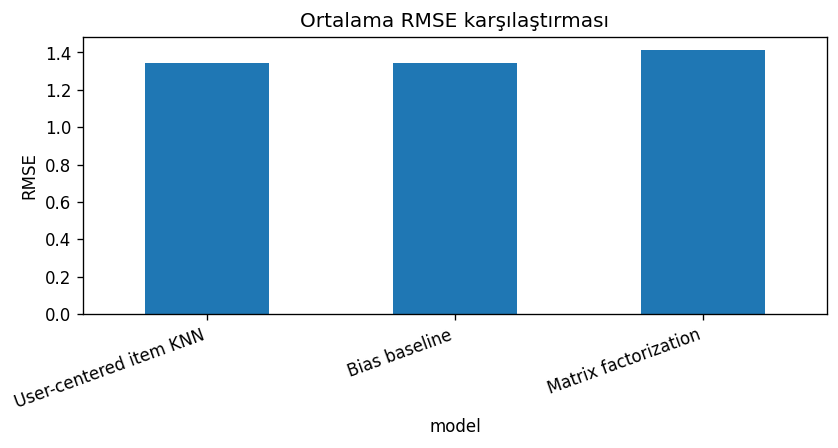

In [20]:
mean_rmse = cv_results.groupby("model")["RMSE"].mean().sort_values()

ax = mean_rmse.plot(kind="bar", figsize=(8, 3))
ax.set_title("Ortalama RMSE karşılaştırması")
ax.set_xlabel("model")
ax.set_ylabel("RMSE")
plt.xticks(rotation=20, ha="right")
plt.show()

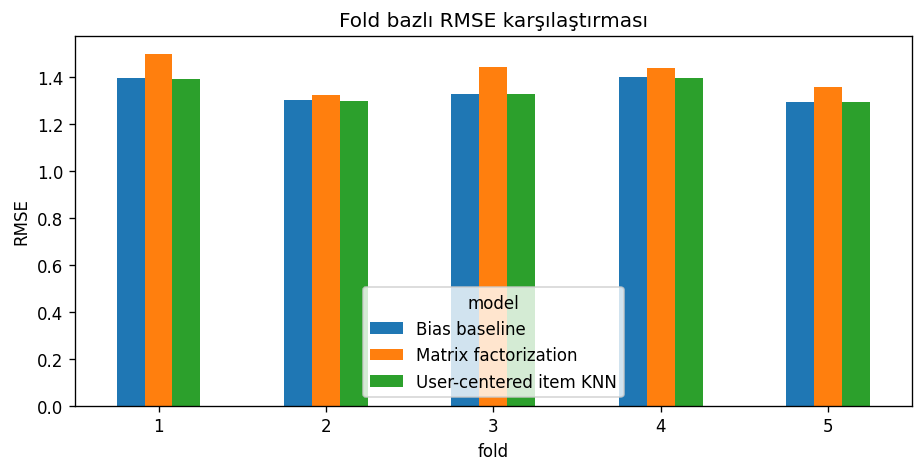

In [21]:
plot_df = cv_results.pivot(index="fold", columns="model", values="RMSE")

ax = plot_df.plot(kind="bar", figsize=(9, 4))
ax.set_title("Fold bazlı RMSE karşılaştırması")
ax.set_xlabel("fold")
ax.set_ylabel("RMSE")
plt.xticks(rotation=0)
plt.show()

## 10. Eğitim kaybı kontrolü

Aşağıdaki grafik son fold'daki MF modelinin train RMSE eğrisidir. Amaç modelin patlamadığını görmek.

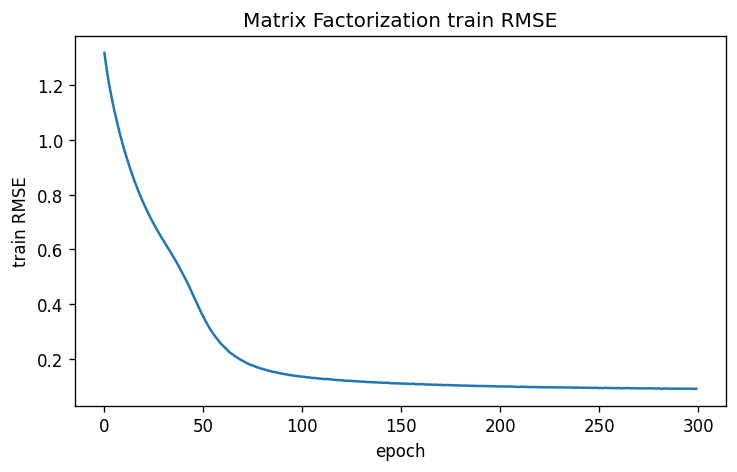

In [22]:
ax = pd.Series(last_mf_model.train_loss_).plot(figsize=(7, 4))
ax.set_title("Matrix Factorization train RMSE")
ax.set_xlabel("epoch")
ax.set_ylabel("train RMSE")
plt.show()

## 11. Tahminleri görsel kontrol et

Sadece skor tablosu yetmez. Gerçek rating ile tahminler ne kadar hizalanmış, ona da bakıyoruz.

In [23]:
best_model_name = mean_rmse.index[0]
best_pred_col = f"{best_model_name}_pred"

pred_check = last_fold_predictions[["userId", "movieId", "rating", best_pred_col]].copy()
pred_check = pred_check.rename(columns={best_pred_col: "pred_rating"})
pred_check["pred_rating"] = pred_check["pred_rating"].round(3)
pred_check["error"] = (pred_check["rating"] - pred_check["pred_rating"]).round(3)
pred_check["abs_error"] = pred_check["error"].abs().round(3)

print("Görsel kontrol edilen model:", best_model_name)
pred_check.sort_values("abs_error", ascending=False).head(10)

Görsel kontrol edilen model: User-centered item KNN


,userId,movieId,rating,pred_rating,error,abs_error
32,15,71,5.0,2.670,2.330,2.330
19,8,784,5.0,2.724,2.276,2.276
11,5,376,1.0,3.271,-2.271,2.271
2,1,286,5.0,2.754,2.246,2.246
25,12,907,1.0,3.111,-2.111,2.111
22,11,59,1.0,3.020,-2.020,2.020
30,14,471,5.0,3.031,1.969,1.969
34,16,203,1.0,2.956,-1.956,1.956
27,13,356,1.0,2.873,-1.873,1.873
1,1,129,1.0,2.754,-1.754,1.754


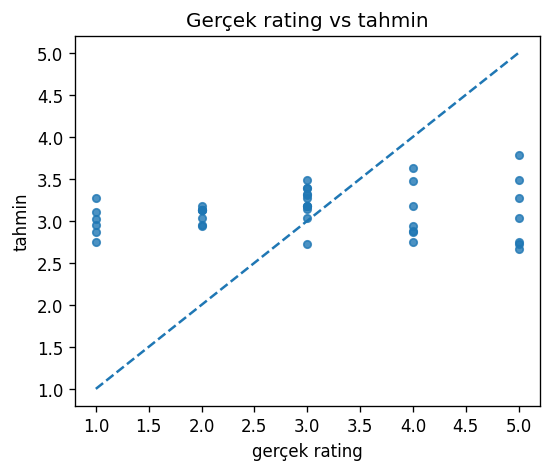

In [24]:
ax = pred_check.plot(
    kind="scatter",
    x="rating",
    y="pred_rating",
    figsize=(5, 4),
    alpha=0.8
)
ax.plot([1, 5], [1, 5], linestyle="--")
ax.set_title("Gerçek rating vs tahmin")
ax.set_xlabel("gerçek rating")
ax.set_ylabel("tahmin")
plt.show()

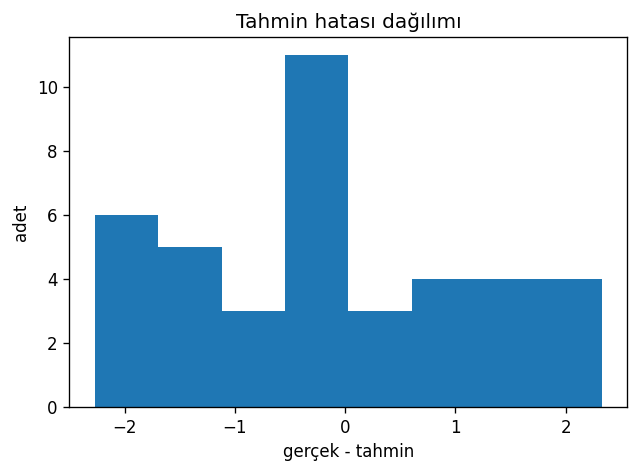

In [25]:
ax = pred_check["error"].plot(kind="hist", bins=8, figsize=(6, 4))
ax.set_title("Tahmin hatası dağılımı")
ax.set_xlabel("gerçek - tahmin")
ax.set_ylabel("adet")
plt.show()

## 12. Basit öneri fonksiyonu

Film isimleri olmadığı için sadece `movieId` öneriyoruz.

Önemli detay: Hiç görülmemiş movieId'leri önermiyoruz. Sadece datada gerçekten rating almış filmler arasından öneri yapıyoruz.

In [26]:
final_model = UserCenteredItemKNN(k=5).fit(df)
known_movies = (
    df[["movieId", "movie_idx"]]
    .drop_duplicates()
    .sort_values("movieId")
    .reset_index(drop=True)
)


def recommend_for_user(user_id, top_n=5):
    rated_movies = set(df.loc[df["userId"] == user_id, "movieId"])
    user_idx = user_to_idx.get(user_id, -1)

    candidates = known_movies.loc[~known_movies["movieId"].isin(rated_movies)].copy()
    candidates["userId"] = user_id
    candidates["user_idx"] = user_idx
    candidates["rating"] = np.nan

    pred_input = candidates[["userId", "movieId", "user_idx", "movie_idx", "rating"]].copy()
    candidates["pred_rating"] = final_model.predict(pred_input)

    return (
        candidates[["userId", "movieId", "pred_rating"]]
        .sort_values("pred_rating", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

example_user = df["userId"].iloc[0]
recommend_for_user(user_id=example_user, top_n=10)

,userId,movieId,pred_rating
0,0,201,5.000000
1,0,22,5.000000
2,0,241,5.000000
3,0,758,3.534199
4,0,744,3.526389
5,0,428,3.505764
6,0,508,3.505159
7,0,286,3.491239
8,0,397,3.491239
9,0,336,3.491239


## Sonuç

Bu implementation'da ana doğru kararlar:

- Data sparse olduğu için missing değerleri 0 yapmadık.
- `movieId` değerlerini direkt matris boyutu gibi kullanmadık; iç indekslere çevirdik.
- Split'i dense matrix üzerinden değil, observed rating satırları üzerinden yaptık.
- K-Fold kullandık çünkü 200 satırda tek split güvenilir olmazdı.
- Rating tahmini için accuracy değil, RMSE ve MAE kullandık.
- R² kullanmadık; bu problemde ana metrik gibi davranması yanıltıcı olabilir.
- Baseline kurduk; diğer modellerin gerçekten değer katıp katmadığını bununla kıyasladık.
- Ekstra olarak user-centered item KNN ekledik. Bu, kullanıcının rating verme alışkanlığını merkeze aldığı için probleme daha uyumlu bir hamle.
- MovieId'ye sin/cos gibi dönüşüm yapmadık çünkü movieId'de dairesel veya sıralı anlam yok.

Kısacası model çok büyük iddia atmıyor. Ama sparse rating datasına göre implementation mantığı doğru, metrik doğru, görseller açıklayıcı ve sonuç yorumu dürüst. baseline’a çok yakın ama az farkla daha iyi ama o kadar yani dahası yoktur.